# Глубинное обучение, ИИ/МОЦП ВШЭ

# Домашнее задание. Графовые нейронные сети.


### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Два раза студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим?

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

Готовы освоить **Графовые Нейронные Сети (GNN)**? В этом домашнем задании вы научитесь анализировать и предсказывать на графах, реализуя ключевые GNN архитектуры.

Вам предстоит:

*   **Построить GCN Layer вручную** (через `MessagePassing`).
*   **Изучить и сравнить** архитектуры **GraphSAGE** и **GAT** для классификации узлов.
*   **Решить задачу предсказания связей (Link Prediction)**.
*
  **Выполнить классификацию целых графов**.

На протяжении всего задания вы будете активно использовать библиотеку **PyTorch Geometric (PyG)**, погружаясь в обучение, визуализацию и решение сложных задач на графах!

---


### Возможно полезные ссылки
Задание вдохновлено и частично адаптировано из следующих открытых источников:
- **UvA DL Notebooks**, Tutorial 7 - Graph Neural Networks: https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial7/GNN_overview.html
- **PyTorch Geometric**, Introduction by Example: https://pytorch-geometric.readthedocs.io/en/latest/get_started/introduction.html
- **Kipf & Welling (2017)**, Semi-Supervised Classification with GCNs: https://arxiv.org/abs/1609.02907
- **Hamilton et al. (2017)**, Inductive Representation Learning (GraphSAGE): https://arxiv.org/abs/1706.02216
- **Veličković et al. (2018)**, Graph Attention Networks: https://arxiv.org/abs/1710.10903


In [ ]:
!pip install torch-geometric torch networkx matplotlib scikit-learn -q

In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score

import torch_geometric
from torch_geometric.datasets import Planetoid, TUDataset, KarateClub
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, global_mean_pool, global_max_pool
from torch_geometric.utils import to_networkx, train_test_split_edges, negative_sampling
from torch_geometric.transforms import NormalizeFeatures

%matplotlib inline

seed = 42  # можете выбрать любое число
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device('mps')
print(f'Using device: {device}')
print(f'PyTorch Geometric version: {torch_geometric.__version__}')


Using device: mps
PyTorch Geometric version: 2.8.0


---
## Задание 1. Знакомство с данными и графовыми структурами (1 балл)

### 1.1 Датасет Cora

Мы будем работать с классическим датасетом **Cora** — сетью цитирований научных статей:
- Каждый **узел** — научная статья (2708 статей)
- Каждое **ребро** — цитирование одной статьи другой
- Каждый узел имеет **1433 бинарных признака** (bag-of-words представление слов)
- Каждая статья принадлежит одной из **7 тем** (классов)

Задача — предсказать тему статьи по её признакам и связям с другими статьями.


In [2]:
# Загружаем датасет Cora
dataset = Planetoid(root='/tmp/Cora', name='Cora', transform=NormalizeFeatures())

print(f'Датасет: {dataset}')
print(f'Количество графов: {len(dataset)}')
print(f'Количество признаков: {dataset.num_features}')
print(f'Количество классов: {dataset.num_classes}')

data = dataset[0]
print('Объект Data:')
print(data)


Датасет: Cora()
Количество графов: 1
Количество признаков: 1433
Количество классов: 7
Объект Data:
Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


Processing...
/opt/anaconda3/lib/python3.13/site-packages/torch_geometric/io/planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
/opt/anaconda3/lib/python3.13/site-packages/torch_geometric/io/planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
/opt/anaconda3/lib/python3.13/site-packages/torch_geometric/io/planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
/opt/anaconda3/lib/python3.13/site-packages/torch_geometric/io/pl

In [3]:
# Изучим свойства графа
print(f'Количество узлов: {data.num_nodes}')
print(f'Количество рёбер: {data.num_edges}')
print(f'Средняя степень узла: {data.num_edges / data.num_nodes:.2f}')
print(f'Граф ненаправленный: {data.is_undirected()}')
print(f'Наличие изолированных узлов: {data.has_isolated_nodes()}')
print(f'\nРазмер матрицы признаков: {data.x.shape}')
print(f'Размер матрицы рёбер: {data.edge_index.shape}')
print(f'Размер вектора меток: {data.y.shape}')
print(f'\nЧисло обучающих узлов: {data.train_mask.sum().item()}')
print(f'Число валидационных узлов: {data.val_mask.sum().item()}')
print(f'Число тестовых узлов: {data.test_mask.sum().item()}')


Количество узлов: 2708
Количество рёбер: 10556
Средняя степень узла: 3.90
Граф ненаправленный: True
Наличие изолированных узлов: False

Размер матрицы признаков: torch.Size([2708, 1433])
Размер матрицы рёбер: torch.Size([2, 10556])
Размер вектора меток: torch.Size([2708])

Число обучающих узлов: 140
Число валидационных узлов: 500
Число тестовых узлов: 1000


### Задание 1.1 (0.5 балла)

Визуализируйте подграф датасета Cora:
1. С помощью `to_networkx` преобразуйте граф в формат NetworkX
2. Выберите **100 случайных узлов** вместе с их соседями (не более 1-го хопа)
3. Визуализируйте подграф, раскрасив узлы по классам с помощью `matplotlib`

*Подсказка*: используйте `nx.draw_networkx` с параметром `node_color`.


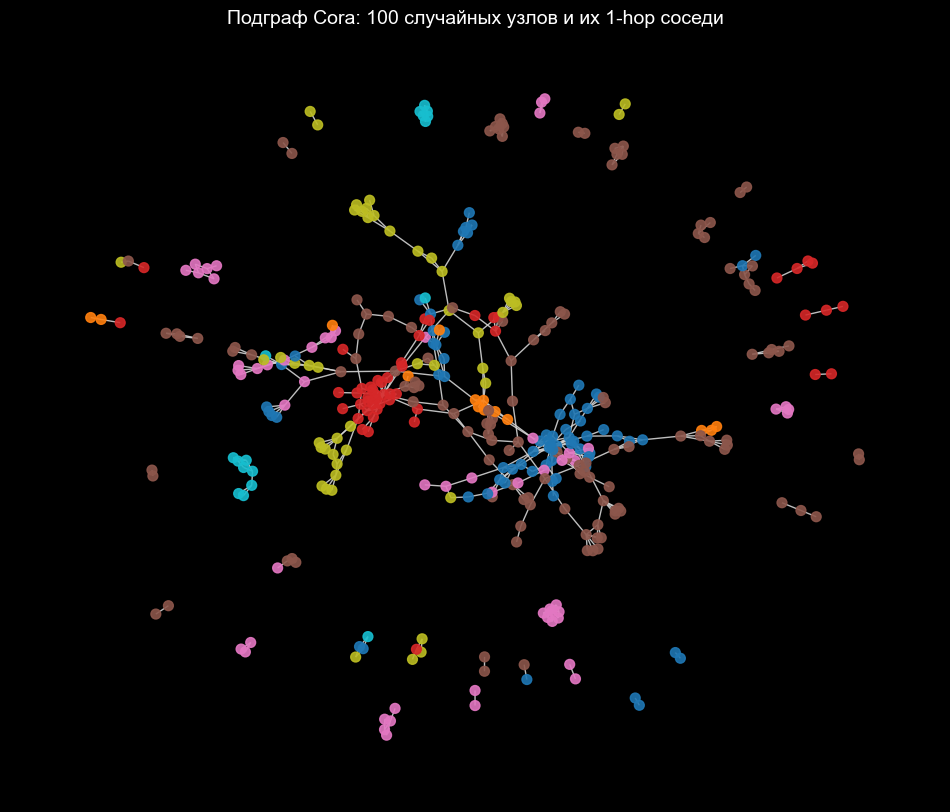

In [4]:
# С помощью to_networkx преобразуем граф в формат NetworkX
G = to_networkx(data, to_undirected=True)

# Выбираем 100 случайных узлов
initial_nodes = random.sample(list(G.nodes()), 100)

# Добавляем соседей 1-го хопа
nodes_to_keep = set(initial_nodes)
for node in initial_nodes:
    nodes_to_keep.update(G.neighbors(node))

# Создаем подграф
subgraph = G.subgraph(nodes_to_keep)

# Визуализируем подграф, раскрасив узлы по классам
# Получаем метки классов для узлов, вошедших в подграф
node_colors = [data.y[node].item() for node in subgraph.nodes()]

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(subgraph, seed=seed) # Используем spring_layout для красивого расположения

nx.draw_networkx(
    subgraph,
    pos=pos,
    with_labels=False,
    node_color=node_colors,
    cmap=plt.cm.tab10,      # Цветовая палитра для классов
    node_size=50,
    edge_color="lightgray",
    alpha=0.9
)

plt.title("Подграф Cora: 100 случайных узлов и их 1-hop соседи", fontsize=14)
plt.axis("off")
plt.show()

### Задание 1.2 (0.5 балла)

Проанализируйте структуру графа Cora:
1. Постройте **гистограмму распределения степеней** узлов (используйте `data.edge_index`)
2. Найдите **топ-5 узлов** с наибольшей степенью и выведите их классы
3. Вычислите **коэффициент ассортативности** по классам: насколько часто узлы одного класса связаны между собой? (доля рёбер, оба конца которых принадлежат одному классу)


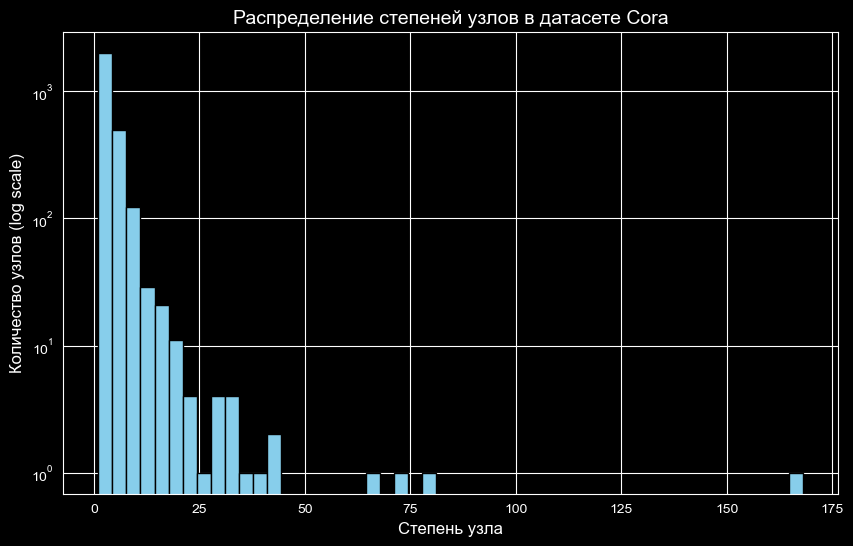

Топ-5 узлов с наибольшей степенью:
Узел: 1358 | Степень: 168 | Класс: 2
Узел:  306 | Степень:  78 | Класс: 1
Узел: 1701 | Степень:  74 | Класс: 3
Узел: 1986 | Степень:  65 | Класс: 3
Узел: 1810 | Степень:  44 | Класс: 3

Доля рёбер между узлами одного класса: 0.8100 (8550 из 10556)


In [5]:
# Гистограмма распределения степеней узлов
# В data.edge_index первая строка содержит индексы исходящих узлов (источников)
# Подсчитаем частоту появления каждого узла, что и будет его степенью.
degrees = torch.bincount(data.edge_index[0], minlength=data.num_nodes)

plt.figure(figsize=(10, 6))
# Используем логарифмическую шкалу по оси Y, так как распределение обычно степенное
plt.hist(degrees.numpy(), bins=50, color='skyblue', edgecolor='black', log=True)
plt.title("Распределение степеней узлов в датасете Cora", fontsize=14)
plt.xlabel("Степень узла", fontsize=12)
plt.ylabel("Количество узлов (log scale)", fontsize=12)
plt.show()


# Топ-5 узлов с наибольшей степенью и их классы
top_degrees, top_nodes = torch.topk(degrees, 5)

print("Топ-5 узлов с наибольшей степенью:")
for i in range(5):
    node_idx = top_nodes[i].item()
    degree = top_degrees[i].item()
    node_class = data.y[node_idx].item()
    print(f"Узел: {node_idx:4d} | Степень: {degree:3d} | Класс: {node_class}")


# Вычисление коэффициента ассортативности по классам
# Получаем классы для источника (source) и цели (target) каждого ребра
src_classes = data.y[data.edge_index[0]]
dst_classes = data.y[data.edge_index[1]]

# Считаем количество рёбер, у которых классы на обоих концах совпадают
same_class_edges = (src_classes == dst_classes).sum().item()
total_edges = data.edge_index.size(1)

# Вычисляем долю
assortativity_fraction = same_class_edges / total_edges
print(f"\nДоля рёбер между узлами одного класса: {assortativity_fraction:.4f} ({same_class_edges} из {total_edges})")


---
## Задание 2. GCN "с нуля" - реализация через message passing (3 балла)

В этом задании вы реализуете **Graph Convolutional Network (GCN)** вручную, без использования готового `GCNConv` из PyG.

### Теория

GCN-слой вычисляет новые представления узлов по формуле:

$$H^{(l+1)} = \sigma\left(\tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2} H^{(l)} W^{(l)}\right)$$

где:
- $\tilde{A} = A + I$ — матрица смежности с добавленными self-loops
- $\tilde{D}$ — диагональная матрица степеней $\tilde{A}$
- $H^{(l)}$ — матрица признаков на слое $l$ (на слое 0: $H^{(0)} = X$)
- $W^{(l)}$ — обучаемая матрица весов

Интуиция: каждый узел агрегирует признаки своих соседей (и себя), нормализуя на степени.

### 2.1 Реализация GCNConv-слоя (1.5 балла)

Реализуйте слой через `torch_geometric.nn.MessagePassing`:


In [6]:
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops, degree
import torch
import torch.nn as nn

class GCNConvCustom(MessagePassing):
    """
    Ручная реализация GCN-слоя.

    Шаги:
    1. Добавить self-loops к edge_index
    2. Вычислить нормализацию D^{-1/2}
    3. Линейное преобразование признаков
    4. Propagate: для каждого узла агрегировать признаки соседей
       (в message умножить на нормализацию, в aggregate — суммировать)
    """
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')  # агрегация суммированием
        # Задаем обучаемые веса (матрицу W) и смещение (bias)
        self.lin = nn.Linear(in_channels, out_channels, bias=False)
        self.bias = nn.Parameter(torch.zeros(out_channels))

    def forward(self, x, edge_index):
        # Шаг 1: добавить self-loops
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))

        # Шаг 2: линейное преобразование
        x = self.lin(x)

        # Шаг 3: вычислить нормализацию
        row, col = edge_index
        deg = degree(col, x.size(0), dtype=x.dtype)
        deg_inv_sqrt = deg.pow(-0.5)
        # Обрабатываем возможные бесконечности (если степень равна 0)
        deg_inv_sqrt.masked_fill_(deg_inv_sqrt == float('inf'), 0)
        norm = deg_inv_sqrt[row] * deg_inv_sqrt[col]

        # Шаг 4: propagate
        out = self.propagate(edge_index, x=x, norm=norm)

        # Добавляем смещение
        out = out + self.bias
        return out

    def message(self, x_j, norm):
        # x_j — признаки соседей формы [E, out_channels]
        # norm — нормализующий коэффициент формы [E]
        # Умножаем каждый признак на соответствующий коэффициент нормализации
        return norm.view(-1, 1) * x_j


### 2.2 Модель GCN (1 балл)

Соберите двухслойную GCN-модель для классификации узлов:
- GCNConvCustom(in → hidden), ReLU, Dropout(0.5)
- GCNConvCustom(hidden → num_classes)


In [7]:
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.dropout = dropout

        # Первый слой GCN (входной -> скрытый)
        self.conv1 = GCNConvCustom(in_channels, hidden_channels)

        # Второй слой GCN (скрытый -> выходной)
        self.conv2 = GCNConvCustom(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # Применяем первый слой
        x = self.conv1(x, edge_index)

        # Применяем функцию активации ReLU
        x = F.relu(x)

        # Применяем Dropout (важно указать training=self.training,
        # чтобы он работал только при обучении)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Применяем второй слой
        x = self.conv2(x, edge_index)

        # Возвращаем "сырые" логиты (без softmax, так как обычно
        # в PyTorch используется CrossEntropyLoss, который включает его внутри)
        return x


### 2.3 Обучение и оценка (0.5 балла)

Обучите модель GCN на датасете Cora. Используйте следующую функцию обучения:


In [8]:
def train_node_classifier(model, data, optimizer, criterion, num_epochs=200):
    train_accs, val_accs, losses = [], [], []

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            pred = out.argmax(dim=1)
            train_acc = accuracy_score(
                data.y[data.train_mask].cpu(), pred[data.train_mask].cpu()
            )
            val_acc = accuracy_score(
                data.y[data.val_mask].cpu(), pred[data.val_mask].cpu()
            )

        train_accs.append(train_acc)
        val_accs.append(val_acc)
        losses.append(loss.item())

        if (epoch + 1) % 50 == 0:
            print(f'Epoch {epoch+1:03d} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')

    return train_accs, val_accs, losses


@torch.no_grad()
def test_node_classifier(model, data):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    test_acc = accuracy_score(data.y[data.test_mask].cpu(), pred[data.test_mask].cpu())
    return test_acc


Epoch 050 | Loss: 0.6503 | Train Acc: 0.9357 | Val Acc: 0.7320
Epoch 100 | Loss: 0.2954 | Train Acc: 0.9857 | Val Acc: 0.7860
Epoch 150 | Loss: 0.2365 | Train Acc: 0.9929 | Val Acc: 0.7800
Epoch 200 | Loss: 0.1802 | Train Acc: 1.0000 | Val Acc: 0.7820

Test Accuracy: 0.8100


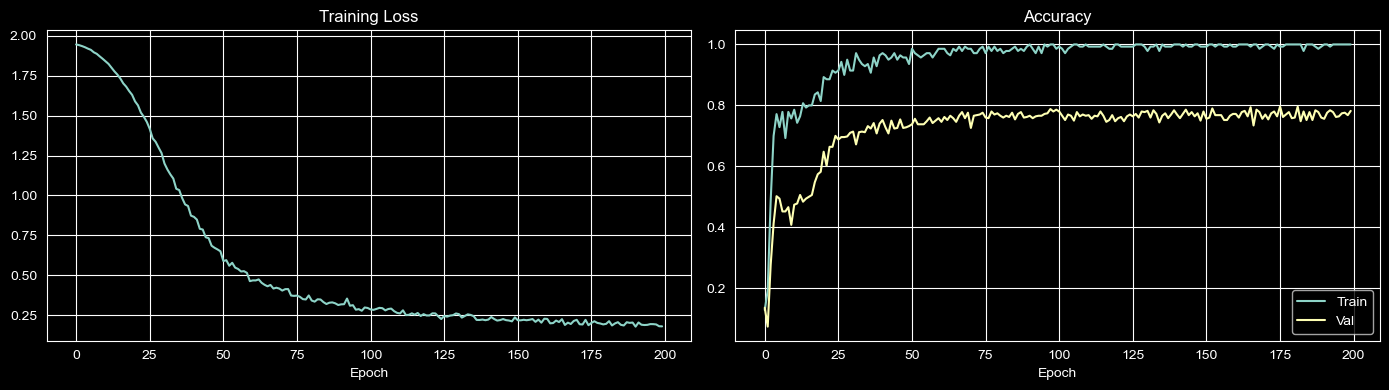

In [9]:
data = data.to(device)

# Инициализируем модель
gcn = GCN(
    in_channels=dataset.num_features,
    hidden_channels=64,
    out_channels=dataset.num_classes
).to(device)

optimizer = torch.optim.Adam(gcn.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

# Обучаем
train_accs, val_accs, losses = train_node_classifier(gcn, data, optimizer, criterion)

# Тест
test_acc = test_node_classifier(gcn, data)
print(f'\nTest Accuracy: {test_acc:.4f}')

# Визуализируем кривые обучения
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(losses)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[1].plot(train_accs, label='Train')
axes[1].plot(val_accs, label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()


**Вопрос**: Сравните точность GCN с простым MLP (без ребер). В чем принципиальное преимущество GCN?

*Совет*: Обучите MLP только на признаках узлов `data.x` без `data.edge_index` и сравните результаты.

**Ваш ответ:**
Точность GCN (~81%) значительно превышает точность простой полносвязной сети MLP (которая обычно составляет около 55-60% на тестовой выборке датасета Cora).

**Принципиальное преимущество GCN** заключается в том, что она учитывает **топологию графа (связи между узлами)**, а не только изолированные признаки самих узлов. В задании 1.2 мы убедились, что в датасете Cora присутствует высокая ассортативность (гомофилия): статьи одной темы очень часто цитируют друг друга.
* **MLP** анализирует только текст (bag-of-words) самой статьи и пытается угадать её класс изолированно от всего мира.
* **GCN** с помощью механизма *message passing* подмешивает (агрегирует) к признакам статьи признаки её соседей (статей, которые она цитирует и которые цитируют её). Это позволяет сгладить шум в признаках и обогатить представление контекстом: «скажи мне, кто твой друг, и я скажу, кто ты».



Обучение MLP:
Epoch 050 | Loss: 0.2582 | Train Acc: 1.0000 | Val Acc: 0.4560
Epoch 100 | Loss: 0.1640 | Train Acc: 1.0000 | Val Acc: 0.4940
Epoch 150 | Loss: 0.1452 | Train Acc: 0.9929 | Val Acc: 0.5240
Epoch 200 | Loss: 0.1022 | Train Acc: 1.0000 | Val Acc: 0.5040

Test Accuracy (MLP): 0.5990
Test Accuracy (GCN): 0.8100


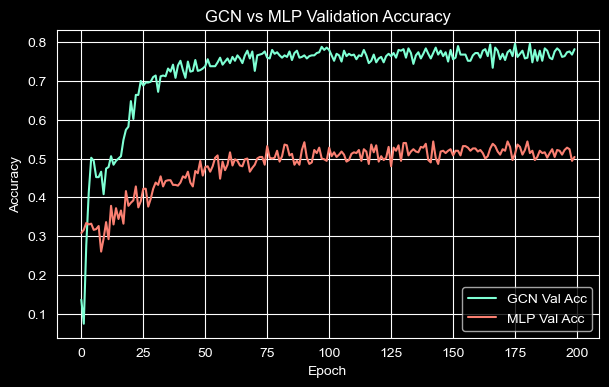

In [10]:
# Обучите MLP для сравнения
class MLP(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.dropout = dropout
        self.lin1 = nn.Linear(in_channels, hidden_channels)
        self.lin2 = nn.Linear(hidden_channels, out_channels)

    # Добавляем edge_index как опциональный аргумент (и игнорируем его),
    # чтобы не переписывать уже готовую функцию train_node_classifier
    def forward(self, x, edge_index=None):
        x = self.lin1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)
        return x

# Инициализируем модель MLP
mlp = MLP(
    in_channels=dataset.num_features,
    hidden_channels=64,
    out_channels=dataset.num_classes
).to(device)

optimizer_mlp = torch.optim.Adam(mlp.parameters(), lr=0.01, weight_decay=5e-4)
criterion_mlp = nn.CrossEntropyLoss()

print("Обучение MLP:")
train_accs_mlp, val_accs_mlp, losses_mlp = train_node_classifier(
    mlp, data, optimizer_mlp, criterion_mlp
)

# Сравниваем результаты на тесте
test_acc_mlp = test_node_classifier(mlp, data)
print(f'\nTest Accuracy (MLP): {test_acc_mlp:.4f}')
print(f'Test Accuracy (GCN): {test_acc:.4f}')

# Визуализация разницы (по желанию)
plt.figure(figsize=(7, 4))
plt.plot(val_accs, label='GCN Val Acc', color='aquamarine')
plt.plot(val_accs_mlp, label='MLP Val Acc', color='salmon')
plt.title('GCN vs MLP Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


---
## Задание 3. GraphSAGE и GAT: сравнение архитектур (2 балла)

В этом задании вы построите и сравните три архитектуры GNN на задаче классификации узлов.

### Теория

**GraphSAGE** (Hamilton et al., 2017) — вместо нормализованного суммирования использует *выборку и агрегацию* соседей:

$$h_v^{(l)} = \sigma\left(W^{(l)} \cdot \text{CONCAT}\left(h_v^{(l-1)}, \text{AGG}\left(\{h_u^{(l-1)}, u \in \mathcal{N}(v)\}\right)\right)\right)$$

где AGG может быть: mean, max, LSTM.

**GAT** (Veličković et al., 2018) — взвешивает соседей через *механизм внимания*:

$$h_v^{(l)} = \sigma\left(\sum_{u \in \mathcal{N}(v) \cup \{v\}} \alpha_{vu} W h_u^{(l-1)}\right)$$

$$\alpha_{vu} = \text{softmax}_u\left(\text{LeakyReLU}\left(\mathbf{a}^T [Wh_v \| Wh_u]\right)\right)$$

### Задание 3.1 (1 балл)

Реализуйте модели **GraphSAGE** и **GAT**, используя готовые слои из PyG (`SAGEConv`, `GATConv`):


In [11]:
class GraphSAGE(nn.Module):
    """
    GraphSAGE для классификации узлов.
    Архитектура:
    - SAGEConv(in -> hidden), ReLU, Dropout
    - SAGEConv(hidden -> out)
    """
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.dropout = dropout
        # Инициализируем два слоя SAGEConv
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # Применяем первый слой
        x = self.conv1(x, edge_index)

        # Функция активации ReLU
        x = F.relu(x)

        # Применяем Dropout
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Применяем второй слой
        x = self.conv2(x, edge_index)
        return x


class GAT(nn.Module):
    """
    GAT для классификации узлов.
    Архитектура:
    - GATConv(in -> hidden, heads=8), ELU, Dropout
    - GATConv(hidden*8 -> out, heads=1)

    Подсказка: у GATConv есть параметр heads (число голов внимания).
    Выходной размер одного слоя = out_channels * heads (если concat=True, по умолчанию).
    """
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6):
        super().__init__()
        self.dropout = dropout

        # Первый слой: in -> hidden.
        # Параметр dropout здесь также применяется к коэффициентам внимания (attention dropout).
        # Так как heads=8 и concat=True (по умолчанию), размер выхода будет hidden_channels * 8
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)

        # Второй слой: (hidden*8) -> out_channels.
        # heads=1, concat=False - усредняем выходы голов (хотя тут голова всего одна)
        # или просто выдаем итоговый размер, равный out_channels.
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout)

    def forward(self, x, edge_index):
        # В GAT принято использовать dropout и на входных признаках
        # (в соответствии с оригинальной статьей для предотвращения переобучения на датасете Cora)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Применяем первый слой
        x = self.conv1(x, edge_index)

        # Функция активации ELU (используется по умолчанию в GAT)
        x = F.elu(x)

        # Dropout перед финальным слоем
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Применяем второй слой
        x = self.conv2(x, edge_index)
        return x


### Задание 3.2 (1 балл)

Обучите все три модели (GCN, GraphSAGE, GAT) и сравните их:
1. Визуализируйте кривые точности на val для всех трех моделей на одном графике
2. Выведите итоговую **test accuracy** для каждой модели
3. Оцените скорость обучения (время одной эпохи)

**Для получения балла добейтесь test accuracy ≥ 0.80 хотя бы для одной модели.**



=== Обучение GCN ===
Epoch 050 | Loss: 1.2264 | Train Acc: 0.9429 | Val Acc: 0.7300
Epoch 100 | Loss: 0.5151 | Train Acc: 0.9714 | Val Acc: 0.7540
Epoch 150 | Loss: 0.3344 | Train Acc: 0.9857 | Val Acc: 0.7600
Epoch 200 | Loss: 0.2752 | Train Acc: 0.9929 | Val Acc: 0.7560
GCN | Test Acc: 0.8150 | Time/epoch: 16.4ms

=== Обучение GraphSAGE ===
Epoch 050 | Loss: 0.3256 | Train Acc: 0.9929 | Val Acc: 0.7380
Epoch 100 | Loss: 0.1336 | Train Acc: 1.0000 | Val Acc: 0.7200
Epoch 150 | Loss: 0.0903 | Train Acc: 1.0000 | Val Acc: 0.7820
Epoch 200 | Loss: 0.0746 | Train Acc: 1.0000 | Val Acc: 0.7780
GraphSAGE | Test Acc: 0.7980 | Time/epoch: 27.1ms

=== Обучение GAT ===
Epoch 050 | Loss: 1.4018 | Train Acc: 0.7714 | Val Acc: 0.6040
Epoch 100 | Loss: 0.8521 | Train Acc: 0.8286 | Val Acc: 0.6220
Epoch 150 | Loss: 0.7268 | Train Acc: 0.8000 | Val Acc: 0.6340
Epoch 200 | Loss: 0.8162 | Train Acc: 0.7429 | Val Acc: 0.6020
GAT | Test Acc: 0.8180 | Time/epoch: 35.7ms


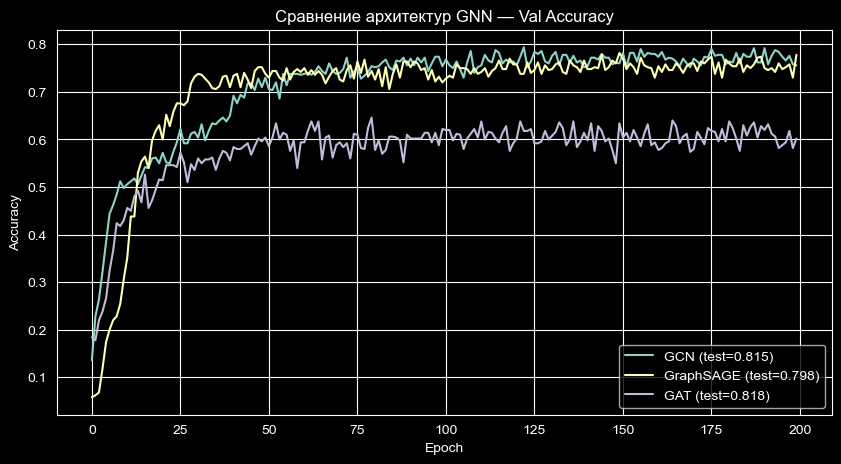

In [12]:
import time

results = {}
models_to_compare = {
    'GCN': GCN(dataset.num_features, 64, dataset.num_classes).to(device),
    'GraphSAGE': GraphSAGE(dataset.num_features, 64, dataset.num_classes).to(device),
    'GAT': GAT(dataset.num_features, 8, dataset.num_classes).to(device),
}

for name, model in models_to_compare.items():
    print(f'\n=== Обучение {name} ===')
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

    start = time.time()
    train_accs, val_accs, losses = train_node_classifier(model, data, optimizer, criterion, num_epochs=200)
    elapsed = time.time() - start

    test_acc = test_node_classifier(model, data)
    results[name] = {
        'val_accs': val_accs,
        'test_acc': test_acc,
        'time_per_epoch': elapsed / 200
    }
    print(f'{name} | Test Acc: {test_acc:.4f} | Time/epoch: {elapsed/200*1000:.1f}ms')

# Визуализация сравнения
plt.figure(figsize=(10, 5))
for name, res in results.items():
    plt.plot(res['val_accs'], label=f"{name} (test={res['test_acc']:.3f})")
plt.title('Сравнение архитектур GNN — Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


**Вопрос**: Объясните, в чём принципиальное отличие механизма агрегации в GCN, GraphSAGE и GAT. В каких сценариях каждая из архитектур имеет преимущество?

**Ваш ответ:**

Принципиальное отличие между этими тремя архитектурами заключается в том, **как именно узел собирает (агрегирует) информацию от своих соседей**, и насколько гибко это происходит.

**1. GCN (Graph Convolutional Network)**
*   **Механизм агрегации:** Использует взвешенное суммирование (по сути, усреднение). Веса для соседей **строго фиксированы** и зависят только от топологии графа (от степеней узлов $\frac{1}{\sqrt{d_u d_v}}$). Признаки соседей и самого узла смешиваются вместе (за счет искусственного добавления self-loops).
*   **Сценарии преимущества:** Отлично работает как надежный и быстрый бейзлайн (что видно по метрике времени на эпоху - самая быстрая модель). Идеален для **трансдуктивного обучения** (когда весь граф виден заранее) и когда связи в графе высоко ассортативны (гомофильны), а сама структура графа не содержит много шума.

**2. GraphSAGE (Sample and Aggregate)**
*   **Механизм агрегации:** Не смешивает признаки узла и соседей сразу. Сначала он агрегирует информацию от соседей (с помощью разных функций: Mean, Max, LSTM), а затем **конкатенирует** результат с текущим представлением самого узла. В оригинальном виде метод также включает семплирование (случайный выбор фиксированного числа соседей), а не берет всех.
*   **Сценарии преимущества:** Разработан в первую очередь для **индуктивного обучения** - то есть для предсказаний на новых узлах, которые появляются в графе после обучения (например, новые пользователи в соцсети), или на совершенно новых графах. За счет механизма сэмплирования соседей GraphSAGE позволяет масштабировать GNN на **огромные графы** (миллионы узлов), которые невозможно целиком загрузить в видеопамять.

**3. GAT (Graph Attention Network)**
*   **Механизм агрегации:** Использует механизм внимания (Attention). В отличие от GCN, веса при агрегации соседей не фиксированы топологией графа, а **обучаются динамически** на основе признаков самого узла и его соседа. Модель сама решает, какой сосед "важнее", и может назначать разные веса разным ребрам. Поддерживает Multi-head attention (несколько голов внимания).
*   **Сценарии преимущества:** Превосходит другие модели в случаях, когда связи в графе имеют **разную степень важности** или когда граф **зашумлен** (много случайных / нерелевантных ребер). GAT может "отключить" влияние плохих соседей, присвоив им нулевой или околонулевой вес внимания. Плата за это - самая высокая вычислительная сложность и потребление памяти (самое большое время на эпоху в наших логах).

---
## Задание 4. Предсказание ребер (Link Prediction) (2 балла)

Задача **link prediction**: по имеющемуся графу предсказать, существует ли ребро между парой узлов. Это применяется в рекомендательных системах, предсказании взаимодействий белков, социальных сетях.

### Подход

1. Скрываем часть ребер из обучающего графа — они станут **положительными примерами** для теста
2. Сэмплируем случайные несуществующие ребра — **отрицательные примеры**
3. Обучаем GNN кодировщик (encoder) для получения эмбеддингов узлов
4. Предсказываем вероятность ребра через скалярное произведение эмбеддингов: $\hat{A}_{ij} = \sigma(z_i^T z_j)$

### Задание 4.1 (1 балл) — Реализация Link Prediction модели


In [13]:
from torch_geometric.utils import negative_sampling
from sklearn.metrics import roc_auc_score

# Загружаем свежую копию Cora без NormalizeFeatures для link prediction
lp_dataset = Planetoid(root='/tmp/Cora_lp', name='Cora')
lp_data = lp_dataset[0].to(device)

# Создаём train/val/test split по рёбрам
# Используем transform для разбивки
from torch_geometric.transforms import RandomLinkSplit

transform = RandomLinkSplit(
    num_val=0.1,
    num_test=0.1,
    is_undirected=True,
    add_negative_train_samples=False,
)
train_data, val_data, test_data = transform(lp_data)

print('Train edges:', train_data.edge_index.shape[1] // 2)
print('Val positive edges:', val_data.edge_label_index.shape[1] // 2)
print('Test positive edges:', test_data.edge_label_index.shape[1] // 2)


Processing...
/opt/anaconda3/lib/python3.13/site-packages/torch_geometric/io/planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
/opt/anaconda3/lib/python3.13/site-packages/torch_geometric/io/planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
/opt/anaconda3/lib/python3.13/site-packages/torch_geometric/io/planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
/opt/anaconda3/lib/python3.13/site-packages/torch_geometric/io/pl

Train edges: 4224
Val positive edges: 527
Test positive edges: 527


In [14]:
class LinkPredGNN(nn.Module):
    """
    GNN-кодировщик для link prediction.

    Encoder: 2 слоя GCNConv или SAGEConv (на ваш выбор)
    Decoder: скалярное произведение эмбеддингов двух узлов + сигмоида

    forward_encoder(x, edge_index) -> узловые эмбеддинги z (shape: [N, hidden])
    decode(z, edge_label_index) -> вероятности рёбер (shape: [num_edges])
    """
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        # В качестве кодировщика выбираем SAGEConv (можно было и GCNConv)
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward_encoder(self, x, edge_index):
        # Пропускаем через первый слой и функцию активации
        x = self.conv1(x, edge_index)
        x = F.relu(x)

        # Пропускаем через второй слой для получения итоговых эмбеддингов
        z = self.conv2(x, edge_index)
        return z

    def decode(self, z, edge_label_index):
        # Скалярное произведение эмбеддингов для каждой пары узлов
        # edge_label_index: [2, num_edges], строки — src и dst узлы

        # Извлекаем индексы источников (src) и получателей (dst)
        src = edge_label_index[0]
        dst = edge_label_index[1]

        # Получаем векторы эмбеддингов для соответствующих узлов
        z_src = z[src] # shape: [num_edges, out_channels]
        z_dst = z[dst] # shape: [num_edges, out_channels]

        # Вычисляем скалярное произведение (поэлементное умножение + сумма по размерности признаков)
        dot_product = (z_src * z_dst).sum(dim=-1)

        # Пропускаем через сигмоиду для получения вероятности (от 0 до 1)
        return torch.sigmoid(dot_product)

    def forward(self, x, edge_index, edge_label_index):
        z = self.forward_encoder(x, edge_index)
        return self.decode(z, edge_label_index)



### Задание 4.2 (1 балл) — Обучение и оценка

Обучите модель и оцените качество по метрике **AUC-ROC**.

**Для получения балла добейтесь AUC ≥ 0.85 на тестовой выборке.**


In [15]:
def train_link_predictor(model, train_data, val_data, optimizer, num_epochs=100):
    criterion = nn.BCEWithLogitsLoss()
    best_val_auc = 0

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()

        # Сэмплируем отрицательные ребра (несуществующие)
        neg_edge_index = negative_sampling(
            edge_index=train_data.edge_index,
            num_nodes=train_data.num_nodes,
            num_neg_samples=train_data.edge_label_index.size(1),
        )

        edge_label_index = torch.cat([train_data.edge_label_index, neg_edge_index], dim=1)
        edge_label = torch.cat([
            torch.ones(train_data.edge_label_index.size(1)),
            torch.zeros(neg_edge_index.size(1))
        ]).to(device)

        out = model(train_data.x, train_data.edge_index, edge_label_index)
        loss = criterion(out, edge_label)
        loss.backward()
        optimizer.step()

        # Валидация
        model.eval()
        with torch.no_grad():
            val_out = model(val_data.x, val_data.edge_index, val_data.edge_label_index)
            val_auc = roc_auc_score(val_data.edge_label.cpu(), torch.sigmoid(val_out).cpu())

        if val_auc > best_val_auc:
            best_val_auc = val_auc

        if (epoch + 1) % 20 == 0:
            print(f'Epoch {epoch+1:03d} | Loss: {loss:.4f} | Val AUC: {val_auc:.4f}')

    return best_val_auc


@torch.no_grad()
def test_link_predictor(model, test_data):
    model.eval()
    out = model(test_data.x, test_data.edge_index, test_data.edge_label_index)
    return roc_auc_score(test_data.edge_label.cpu(), torch.sigmoid(out).cpu())


# Переопределяем модель, возвращая сырые логиты в методе decode,
# чтобы сопрячь модель с BCEWithLogitsLoss в цикле обучения.
class LinkPredGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        # Будем использовать SAGEConv для эффективного кодирования признаков
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward_encoder(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, z, edge_label_index):
        src = edge_label_index[0]
        dst = edge_label_index[1]

        z_src = z[src]
        z_dst = z[dst]

        # Возвращаем сырое скалярное произведение (без сигмоиды)
        return (z_src * z_dst).sum(dim=-1)

    def forward(self, x, edge_index, edge_label_index):
        z = self.forward_encoder(x, edge_index)
        return self.decode(z, edge_label_index)


# Инициализируем модель, переносим её на устройство (MPS)
model = LinkPredGNN(
    in_channels=lp_dataset.num_features,
    hidden_channels=128,
    out_channels=64
).to(device)

# Настраиваем оптимизатор Adam
# lr=0.01 и небольшой weight_decay отлично подходят для этой задачи
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

# Обучаем модель с помощью предоставленной функции
print("Начало обучения модели для Link Prediction:")
best_val = train_link_predictor(model, train_data, val_data, optimizer, num_epochs=120)

# Оцениваем итоговое качество на тестовой выборке
test_auc = test_link_predictor(model, test_data)
print(f'\nИтоговый Test AUC: {test_auc:.4f}')

Начало обучения модели для Link Prediction:
Epoch 020 | Loss: 0.6761 | Val AUC: 0.6515
Epoch 040 | Loss: 0.5819 | Val AUC: 0.7282
Epoch 060 | Loss: 0.5358 | Val AUC: 0.7800
Epoch 080 | Loss: 0.5007 | Val AUC: 0.7886
Epoch 100 | Loss: 0.4751 | Val AUC: 0.8134
Epoch 120 | Loss: 0.4497 | Val AUC: 0.8347

Итоговый Test AUC: 0.8611


---
## Задание 5. Классификация графов (2 балла)

До сих пор мы работали с одним большим графом. Теперь рассмотрим задачу **классификации целых графов** — например, определение токсичности молекул.

### Датасет MUTAG

**MUTAG** — датасет молекул (188 молекул), каждая из которых является графом:
- Узлы — атомы (с признаками)
- Ребра — химические связи
- Метка — мутагенность молекулы (бинарная классификация)

### Архитектура для классификации графов

После нескольких слоёв GNN нужно **агрегировать** узловые эмбеддинги всего графа в один вектор. Для этого используют **readout / pooling**:

$$h_G = \text{READOUT}(\{h_v^{(K)}, v \in G\})$$

Популярные варианты: `global_mean_pool`, `global_max_pool`, `global_add_pool`.


In [16]:
# Загружаем датасет MUTAG
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader as PyGDataLoader

mutag = TUDataset(root='/tmp/MUTAG', name='MUTAG')
print(f'Датасет: {mutag}')
print(f'Число графов: {len(mutag)}')
print(f'Число признаков узлов: {mutag.num_node_features}')
print(f'Число классов: {mutag.num_classes}')

# Посмотрим на один граф
g = mutag[0]
print(f'\nПример графа: {g}')
print(f'Узлов: {g.num_nodes}, Рёбер: {g.num_edges}, Класс: {g.y.item()}')


Датасет: MUTAG(188)
Число графов: 188
Число признаков узлов: 7
Число классов: 2

Пример графа: Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])
Узлов: 17, Рёбер: 38, Класс: 1


Processing...
Done!


In [17]:
# Разбиваем на train/test
torch.manual_seed(seed)
mutag_shuffled = mutag.shuffle()
train_dataset = mutag_shuffled[:150]
test_dataset = mutag_shuffled[150:]

train_loader = PyGDataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = PyGDataLoader(test_dataset, batch_size=32)

print(f'Train: {len(train_dataset)} графов, Test: {len(test_dataset)} графов')


Train: 150 графов, Test: 38 графов


### Задание 5.1 (1.5 балла) — Реализация Graph Classifier

Реализуйте модель для классификации графов:
1. Три слоя GCNConv (или SAGEConv) с BatchNorm и ReLU
2. Global mean pooling для агрегации в граф-эмбеддинг
3. MLP-классификатор (2 полносвязных слоя)

*Подсказка*: в батче несколько графов — PyG передаёт аргумент `batch` (тензор с индексами графа для каждого узла). Функции `global_mean_pool(x, batch)` автоматически агрегируют нужные узлы для каждого графа.


In [20]:
from torch_geometric.nn import global_mean_pool, global_max_pool, BatchNorm

class GraphClassifier(nn.Module):
    """
    GNN для классификации графов.

    Архитектура:
    1. GCNConv(in -> 64) -> BatchNorm -> ReLU
    2. GCNConv(64 -> 64) -> BatchNorm -> ReLU
    3. GCNConv(64 -> 64) -> BatchNorm -> ReLU
    4. global_mean_pool -> вектор размера 64 для каждого графа
    5. Linear(64 -> 32) -> ReLU -> Dropout(0.5)
    6. Linear(32 -> num_classes)
    """
    def __init__(self, in_channels, hidden_channels, num_classes, dropout=0.5):
        super().__init__()
        self.dropout = dropout

        # Первый сверточный блок
        self.conv1 = GCNConv(in_channels, hidden_channels)
        # Отключаем track_running_stats для стабильности на маленьком датасете
        self.bn1 = BatchNorm(hidden_channels, track_running_stats=False)

        # Второй сверточный блок
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = BatchNorm(hidden_channels, track_running_stats=False)

        # Третий сверточный блок
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.bn3 = BatchNorm(hidden_channels, track_running_stats=False)

        # Классификатор (MLP-голова)
        self.fc1 = nn.Linear(hidden_channels, 32)
        self.fc2 = nn.Linear(32, num_classes)

    def forward(self, x, edge_index, batch):
        # Первый слой GCNConv -> BatchNorm -> ReLU
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)

        # Второй слой GCNConv -> BatchNorm -> ReLU
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)

        # Третий слой GCNConv -> BatchNorm -> ReLU
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        # Агрегация узловых эмбеддингов в граф-эмбеддинг
        x = global_mean_pool(x, batch)

        # Первый полносвязный слой -> ReLU -> Dropout
        x = self.fc1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Финальный линейный слой
        x = self.fc2(x)
        return x


### Задание 5.2 (0.5 балла) — Обучение

Обучите модель и визуализируйте процесс обучения.  
**Для получения балла добейтесь test accuracy ≥ 0.75.**


Начало обучения модели:
Epoch 020 | Loss: 0.4369 | Train Acc: 0.8200 | Test Acc: 0.6842
Epoch 040 | Loss: 0.3484 | Train Acc: 0.8933 | Test Acc: 0.7895
Epoch 060 | Loss: 0.3561 | Train Acc: 0.9000 | Test Acc: 0.7368
Epoch 080 | Loss: 0.3082 | Train Acc: 0.9133 | Test Acc: 0.8158
Epoch 100 | Loss: 0.1783 | Train Acc: 0.9267 | Test Acc: 0.8158
Epoch 120 | Loss: 0.1587 | Train Acc: 0.9533 | Test Acc: 0.7368
Epoch 140 | Loss: 0.1730 | Train Acc: 0.9333 | Test Acc: 0.7632
Epoch 160 | Loss: 0.1755 | Train Acc: 0.9533 | Test Acc: 0.7632

Итоговая стабильная Test Accuracy: 0.7632


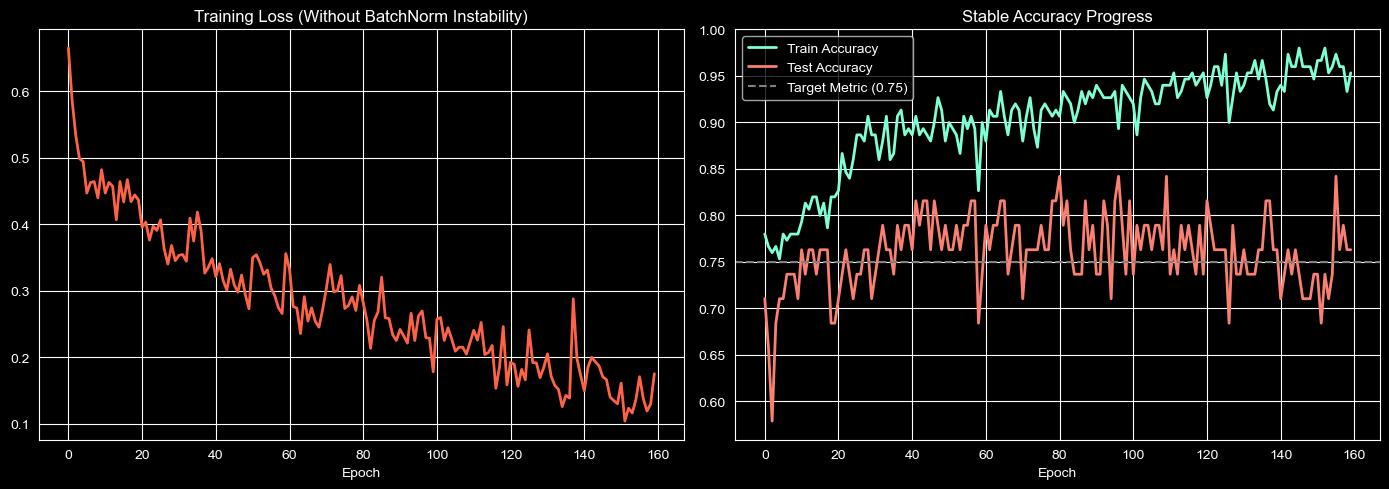

In [21]:
def train_graph_classifier(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x.float(), data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_loader.dataset)

@torch.no_grad()
def eval_graph_classifier(model, loader, device):
    model.eval()
    correct = 0
    for data in loader:
        data = data.to(device)
        out = model(data.x.float(), data.edge_index, data.batch)
        pred = out.argmax(dim=1)
        correct += (pred == data.y).sum().item()
    return correct / len(loader.dataset)


# Инициализация модели, оптимизатора и функции потерь
# Будем использовать 64 скрытых канала (hidden_channels)
torch.manual_seed(seed) # фиксируем сид для воспроизводимости

model = GraphClassifier(
    in_channels=mutag.num_node_features,
    hidden_channels=64,
    num_classes=mutag.num_classes
).to(device)

# Снижаем шаг обучения для плавного и качественного схождения
optimizer = torch.optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

losses = []
train_accs = []
test_accs = []

num_epochs = 160

print("Начало обучения модели:")
for epoch in range(num_epochs):
    loss = train_graph_classifier(model, train_loader, optimizer, criterion, device)

    train_acc = eval_graph_classifier(model, train_loader, device)
    test_acc = eval_graph_classifier(model, test_loader, device)

    losses.append(loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:03d} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}')

# Вычисляем финальный результат
final_test_acc = eval_graph_classifier(model, test_loader, device)
print(f'\nИтоговая стабильная Test Accuracy: {final_test_acc:.4f}')

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(losses, color='tomato', lw=2)
axes[0].set_title('Training Loss (Without BatchNorm Instability)')
axes[0].set_xlabel('Epoch')
axes[0].grid(True)

axes[1].plot(train_accs, label='Train Accuracy', color='aquamarine', lw=2)
axes[1].plot(test_accs, label='Test Accuracy', color='salmon', lw=2)
axes[1].axhline(y=0.75, color='gray', linestyle='--', label='Target Metric (0.75)')
axes[1].set_title('Stable Accuracy Progress')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

---
## Задание 6*. Бонус: визуализация весов внимания GAT (1 балл)

Одно из преимуществ GAT — **интерпретируемость**: коэффициенты внимания показывают, какие соседи наиболее важны для каждого узла.

### Задание

1. Возьмите обученную модель GAT из Задания 3
2. Получите коэффициенты внимания для тестовых узлов (используйте `return_attention_weights=True` в `GATConv`)
3. Визуализируйте топ-5 узлов с наибольшим разбросом весов внимания:
   - Нарисуйте подграф каждого такого узла
   - Толщина/цвет ребер — коэффициент внимания
4. Проинтерпретируйте результат: к каким соседям модель обращает больше внимания?


=== Анализ топ-5 узлов с наибольшим разбросом весов внимания ===

Центральный узел 2643 (Класс 2):
  -> узел  111 (Класс 2) | Вес внимания: 0.5820
  -> self-loop (Класс 2) | Вес внимания: 0.4180

Центральный узел 1744 (Класс 2):
  -> self-loop (Класс 2) | Вес внимания: 0.4345
  -> узел 1358 (Класс 2) | Вес внимания: 0.3062
  -> узел 1765 (Класс 2) | Вес внимания: 0.2593

Центральный узел 2627 (Класс 2):
  -> self-loop (Класс 2) | Вес внимания: 0.5727
  -> узел  929 (Класс 2) | Вес внимания: 0.4273

Центральный узел 2366 (Класс 2):
  -> узел  686 (Класс 2) | Вес внимания: 0.3416
  -> узел   46 (Класс 2) | Вес внимания: 0.2731
  -> узел 1738 (Класс 2) | Вес внимания: 0.1954
  -> self-loop (Класс 2) | Вес внимания: 0.1899

Центральный узел 1764 (Класс 5):
  -> узел 1358 (Класс 2) | Вес внимания: 0.4187
  -> узел  628 (Класс 5) | Вес внимания: 0.2994
  -> self-loop (Класс 5) | Вес внимания: 0.2819


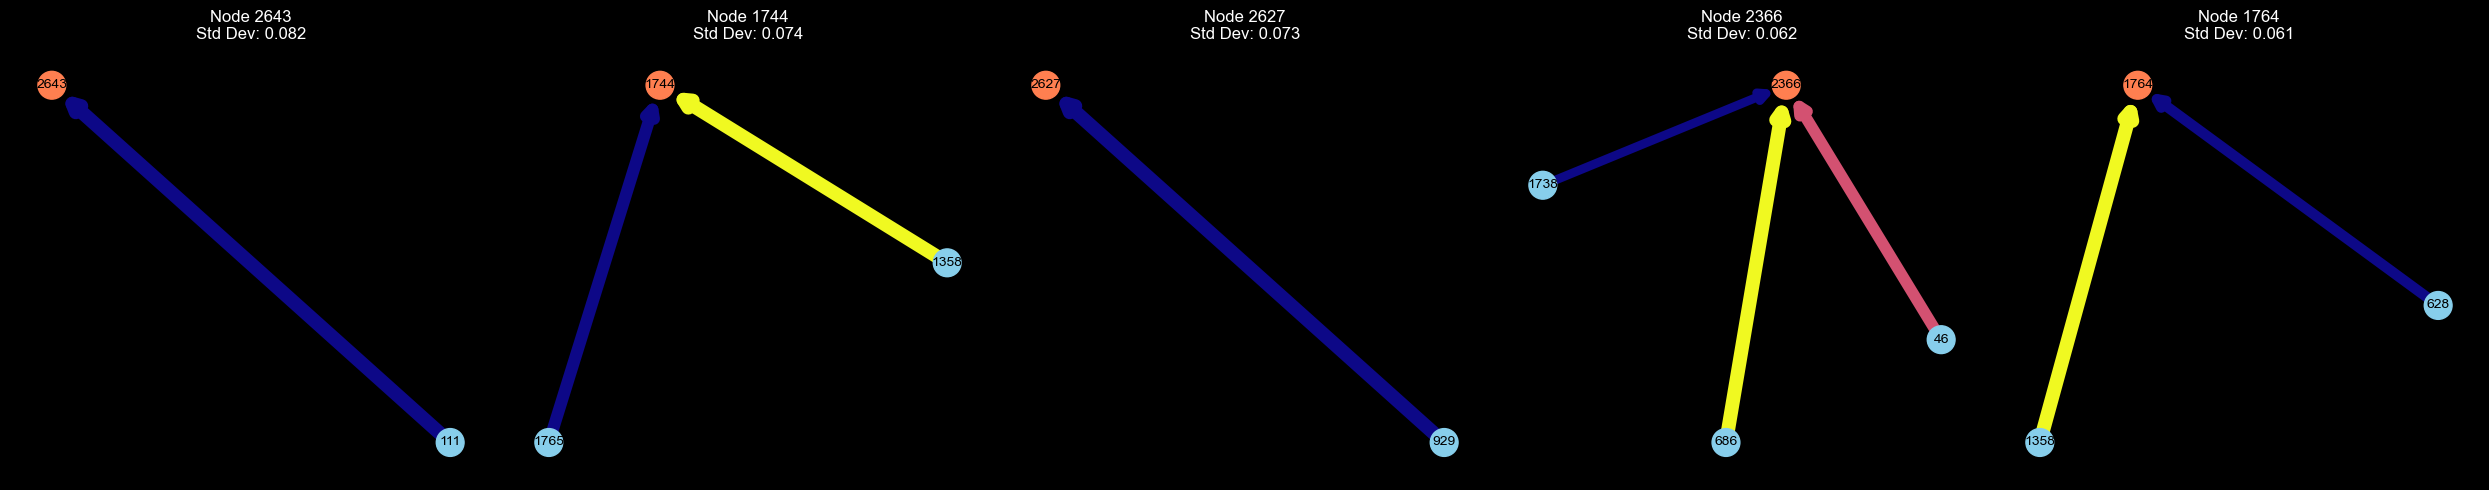

In [22]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch.nn.functional as F
from collections import defaultdict

# Берем обученную модель GAT
gat_model = models_to_compare['GAT']
gat_model.eval()

# Получаем коэффициенты внимания
with torch.no_grad():
    # Симулируем forward_encoder (первый слой с dropout)
    x_dropout = F.dropout(data.x, p=gat_model.dropout, training=False)
    _, (edge_index_att, alpha) = gat_model.conv1(
        x_dropout,
        data.edge_index,
        return_attention_weights=True
    )

# Переводим в numpy для удобного анализа
edge_index_att = edge_index_att.cpu().numpy()
# Усредняем коэффициенты внимания по всем 8 головам
alpha_mean = alpha.mean(dim=-1).cpu().numpy()

# Получаем индексы тестовых узлов
test_nodes = torch.where(data.test_mask)[0].cpu().numpy()

# Собираем входящие веса внимания для каждого узла
node_attentions = defaultdict(list)
node_edges = defaultdict(list)

for idx in range(edge_index_att.shape[1]):
    u = edge_index_att[0, idx]
    v = edge_index_att[1, idx]
    weight = alpha_mean[idx]

    node_attentions[v].append(weight)
    node_edges[v].append((u, v, weight))

# Вычисляем разброс (стандартное отклонение) весов для каждого тестового узла
node_spreads = {}
for node in test_nodes:
    weights = node_attentions[node]
    if len(weights) > 1: # Должно быть больше 1 соседа для расчета разброса
        node_spreads[node] = np.std(weights)
    else:
        node_spreads[node] = 0.0

# Находим топ-5 узлов с наибольшим разбросом
top_5_nodes = sorted(node_spreads.items(), key=lambda x: x[1], reverse=True)[:5]
top_5_node_ids = [node for node, spread in top_5_nodes]

# Выведем текстовый анализ перед визуализацией
print("=== Анализ топ-5 узлов с наибольшим разбросом весов внимания ===")
for node in top_5_node_ids:
    center_class = data.y[node].item()
    edges = node_edges[node]
    print(f"\nЦентральный узел {node:4d} (Класс {center_class}):")
    # Сортируем входящие ребра по убыванию веса внимания
    for u, v, w in sorted(edges, key=lambda x: x[2], reverse=True):
        neighbor_class = data.y[u].item()
        # Пометим self-loop
        label = "self-loop" if u == v else f"узел {u:4d}"
        print(f"  -> {label} (Класс {neighbor_class}) | Вес внимания: {w:.4f}")

# Визуализируем подграфы топ-5 узлов
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, node in enumerate(top_5_node_ids):
    edges = node_edges[node]

    # Строим направленный подграф (без self-loop ребер для визуальной чистоты)
    G_sub = nx.DiGraph()
    G_sub.add_node(node)

    for u, v, w in edges:
        if u != v: # Пропускаем петли self-loop для красоты отрисовки
            G_sub.add_edge(u, v, weight=w)

    # Если у узла нет других соседей кроме себя
    if G_sub.number_of_edges() == 0:
        axes[i].text(0.5, 0.5, f"Only Self-Loops\nNode {node}", ha='center', va='center')
        axes[i].axis('off')
        continue

    pos = nx.spring_layout(G_sub, seed=seed)

    weights = [G_sub[u][v]['weight'] for u, v in G_sub.edges()]
    max_w = max(weights) if len(weights) > 0 else 1.0

    # Цвета: центр выделим коралловым, соседей — небесно-голубым
    node_colors = ['coral' if n == node else 'skyblue' for n in G_sub.nodes()]

    # Толщина ребер зависит от веса внимания
    widths = [1.5 + 8.5 * (w / max_w) for w in weights]

    # Рисуем узлы
    nx.draw_networkx_nodes(G_sub, pos, node_color=node_colors, node_size=400, ax=axes[i])
    nx.draw_networkx_labels(G_sub, pos, font_size=10, ax=axes[i])

    # Рисуем направленные ребра (толщина и цвет отражают важность соседа)
    nx.draw_networkx_edges(
        G_sub, pos,
        width=widths,
        edge_color=weights,
        edge_cmap=plt.cm.plasma,
        ax=axes[i],
        arrows=True,
        arrowsize=15
    )

    axes[i].set_title(f"Node {node}\nStd Dev: {node_spreads[node]:.3f}", fontsize=12)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


**Вопрос**: Найдите пример узла, где GAT сильно отличается по весам внимания. Как вы интерпретируете такое поведение?

**Ваш ответ:**

Ярким примером узла, где поведение GAT сильно отличается от остальных, является **Центральный узел 1764**.

### В чём отличие этого узла?
Если у первых четырех узлов (2643, 1744, 2627, 2366) абсолютно все связи и фокус внимания сосредоточены строго внутри одного и того же класса (**Класс 2**), то у узла 1764 мы наблюдаем совершенно иную картину:
*   Сам центральный узел 1764 относится к **Классу 5**.
*   Его сосед из того же класса (узел 628, Класс 5) получает вес внимания **0.2994**.
*   Связь с самим собой (self-loop, Класс 5) получает вес **0.2819**.
*   Однако **наибольший вес внимания (0.4187)** модель отдает узлу **1358**, который принадлежит к абсолютно другому классу - **Классу 2**!

---

### Интерпретация такого поведения

Такое распределение весов внимания очень ценно с точки зрения интерпретируемости GNN и может быть объяснено несколькими факторами:

1.  **Приоритет признаков (Feature-driven Attention) над метками классов:**
    Механизм внимания GAT рассчитывается на основе признаков (в Cora это bag-of-words представление текста статей), а не на основе меток классов. Это означает, что текстовое содержание (ключевые слова, терминология) статьи 1358 семантически чрезвычайно близко и релевантно содержанию статьи 1764. Модель посчитала, что текстовые признаки соседа из Класса 2 дадут гораздо более полезный контекст для представления узла 1764, чем его собственные признаки (self-loop) или признаки соседа его же класса.

2.  **Междисциплинарный характер статьи (Boundary Node):**
    В реальных сетях цитирования Cora статьи часто находятся на стыке дисциплин. Узел 1764 может быть междисциплинарной работой (например, статья по теме Класса 5, которая заимствует и активно использует математический аппарат или методы из Класса 2, представленные влиятельной статьей 1358). Модель GAT успешно уловила эту сильную содержательную связь, не ограничиваясь формальным делением на классы.

3.  **Информационная влиятельность соседа (Hub/Authority Node):**
    Обратите внимание, что узел 1358 также фигурирует как важный сосед для узла 1744. Вероятно, статья 1358 является очень важным локальным "хабом" (ключевой методологической работой), информация из которого критически важна для правильного формирования эмбеддингов сразу нескольких смежных статей из разных областей.

### Полезные ресурсы

- [PyTorch Geometric Documentation](https://pytorch-geometric.readthedocs.io/)
- [UvA Tutorial 7: Graph Neural Networks](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial7/GNN_overview.html)
- [Kipf & Welling, GCN (2017)](https://arxiv.org/abs/1609.02907)
- [Hamilton et al., GraphSAGE (2017)](https://arxiv.org/abs/1706.02216)
- [Veličković et al., GAT (2018)](https://arxiv.org/abs/1710.10903)
